In [1]:
!pip install pandas
!pip install contractions
!pip install pyLDAvis #3.4.1
!pip install nltk
!pip install --upgrade ipykernel
!pip install wordcloud
!pip install gensim==4.3.2
!pip install seaborn
!pip install umap-learn #0.5.6


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import requests #2.31.0
import pandas as pd #1.5.3
import nltk #3.8.1
nltk.download('punkt')
nltk.download("wordnet")
from nltk.tokenize import sent_tokenize, word_tokenize
import contractions
import re
import os
from string import punctuation
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from pprint import pprint
import gensim.corpora as corpora
from gensim.corpora import Dictionary
#import gensim, spacy, logging, warnings

import pyLDAvis.gensim_models
import pickle
import pyLDAvis

#warnings.filterwarnings("ignore",category=DeprecationWarning)

from gensim.models import CoherenceModel
import numpy as np
import tqdm
import time
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel
from wordcloud import WordCloud,STOPWORDS,ImageColorGenerator
import matplotlib.colors as mcolors

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/thavaseelan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/thavaseelan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/thavaseelan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
data = pd.read_csv("/Users/thavaseelan/Downloads/Dissertation/enrinchment.csv", encoding='unicode_escape')

In [4]:
data.head()

,Unnamed: 0,url,iswayback,title,article,isvalid,article_hash,summary,publish_date,crawl_date,...,tah_ner_location_source,tah_ner_victim_count,nlu_facility,tah_ner_victim_age,tah_ner_victim_age_group,tah_ner_trafficker_gender,wdn,transport_keys,transport_scores,nlu
0,0,https://www.watfordobserver.co.uk/news/nationa...,False,Gang of five convicted of human trafficking an...,At the High Court in Glasgow on Thursday Maria...,True,a5432c46ff2d91b2d63ccab16be6e1bfcd53df88,Detectives said the gang originally from Roman...,2025-01-09,2025-01-10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,https://omaha.com/news/state-regional/crime-co...,False,Nebraska officials again sound alarm on human ...,LINCOLN State and federal law enforcement off...,True,815229d337dd3481cbe7d29aff71b0743668f3c1,LINCOLN State and federal law enforcement off...,NaN,2025-01-10,...,"['Nebraska', 'immunized', ' ']",['12'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,https://mykiss1031.com/ixp/192/p/how-texans-ca...,False,How Texans Can Help Fight Human Trafficking Ac...,If you didnt know January is National Human Tr...,True,036f12a9ce69c69f60c77ac14853e6db4e157a30,Well thanks to Texas DPS we have tools that ca...,NaN,2025-01-10,...,['Texas'],['446'],"[{'name': 'RadioReference Wiki Gallery', 'rele...",['under the age of 18'],['3-17'],NaN,NaN,NaN,NaN,NaN
3,3,https://www.firstpost.com/world/26-ethiopians-...,False,26 Ethiopians rescued from human trafficking i...,South African police rescued 26 Ethiopians fro...,True,7b7142b2e8767b2519f5327d13097945863ab9fe,South African police rescued 26 Ethiopians fro...,2025-01-10,2025-01-10,...,['South Africa'],"['82', '11', '26', '60', '7', '19']",NaN,['minors'],['3-17'],['male'],NaN,NaN,NaN,NaN
4,4,https://www.roadsafety.co.za/2025-01/alleged-h...,False,Alleged human trafficking ring busted in Sandr...,A joint operation between Sandringham SAPS Gau...,True,5fa3e181a052fad3c12996689870a0bdef2ff701,A joint operation between Sandringham SAPS Gau...,2025-01-12,2025-01-10,...,NaN,"['15', '26', '11']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
data.describe()

,Unnamed: 0,classification_score,nlu
count,2636.000000,2636.000000,0.0
mean,1317.500000,0.933688,NaN
std,761.091979,0.123332,NaN
min,0.000000,0.372989,NaN
25%,658.750000,0.941413,NaN
50%,1317.500000,0.993606,NaN
75%,1976.250000,0.998644,NaN
max,2635.000000,0.999434,NaN


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2636 entries, 0 to 2635
Data columns (total 56 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Unnamed: 0                             2636 non-null   int64  
 1   url                                    2636 non-null   object 
 2   iswayback                              2636 non-null   bool   
 3   title                                  2636 non-null   object 
 4   article                                2636 non-null   object 
 5   isvalid                                2636 non-null   bool   
 6   article_hash                           2636 non-null   object 
 7   summary                                2635 non-null   object 
 8   publish_date                           1644 non-null   object 
 9   crawl_date                             2636 non-null   object 
 10  gdeltx                                 118 non-null    object 
 11  trai

In [7]:
data = data[['id_oid','title','article','classification_isincident','training_date']]

In [8]:
data.shape

(2636, 5)

In [9]:
data_article = data[['article']]

In [10]:
# Dropping all the duplicate records
data_article = data_article.drop_duplicates().reset_index(drop=True)
print("Duplicate values dropped in file")

Duplicate values dropped in file


In [11]:
data_article

,article
0,At the High Court in Glasgow on Thursday Maria...
1,LINCOLN State and federal law enforcement off...
2,If you didnt know January is National Human Tr...
3,South African police rescued 26 Ethiopians fro...
4,A joint operation between Sandringham SAPS Gau...
...,...
2623,State Police investigators out of Lyons report...
2624,Attorney General Alan Wilson Attorney General...
2625,Attorney General Alan Wilson Attorney General...
2626,MICHIGAN CITY Ind WNDU A 29yearold Michigan C...


In [12]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/thavaseelan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [13]:
# Calculating number of sentences
data_article["no_sentences_before_cleansing"] = data_article['article'].apply(lambda x : len(sent_tokenize(x)))

In [14]:
data_article

,article,no_sentences_before_cleansing
0,At the High Court in Glasgow on Thursday Maria...,1
1,LINCOLN State and federal law enforcement off...,1
2,If you didnt know January is National Human Tr...,1
3,South African police rescued 26 Ethiopians fro...,1
4,A joint operation between Sandringham SAPS Gau...,1
...,...,...
2623,State Police investigators out of Lyons report...,1
2624,Attorney General Alan Wilson Attorney General...,1
2625,Attorney General Alan Wilson Attorney General...,1
2626,MICHIGAN CITY Ind WNDU A 29yearold Michigan C...,1


/Users/thavaseelan/anaconda3/lib/python3.11/site-packages/wordcloud/wordcloud.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.colormap = plt.cm.get_cmap(colormap)


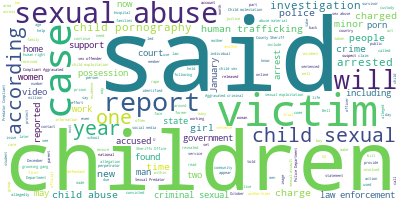

In [15]:
# Import the wordcloud library
from wordcloud import WordCloud

# Join the different processed titles together.
long_string = ','.join(list(data_article['article'].values))

# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=500, contour_width=3, contour_color='steelblue')

# Generate a word cloud
wordcloud.generate(long_string)

# Visualize the word cloud
wordcloud.to_image()

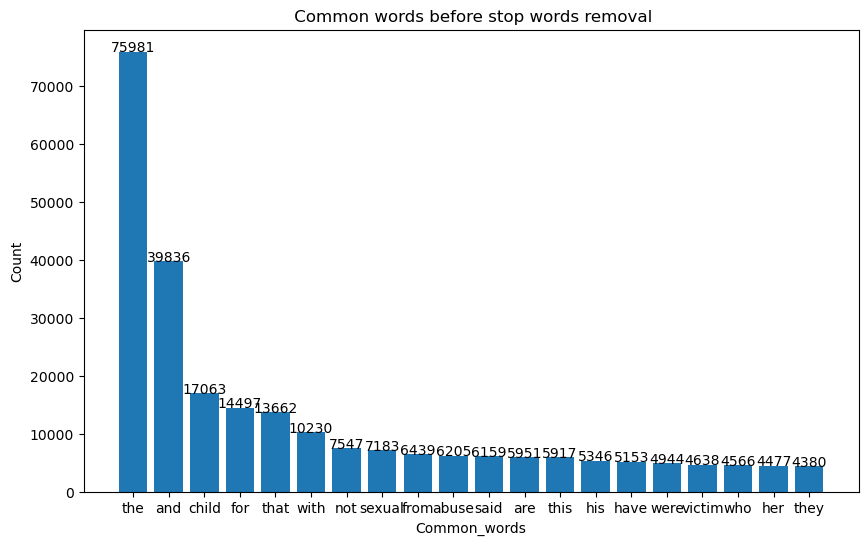

In [16]:
def Text_with_stop_words(text):
    text = str(text).lower() # converting to lower
    text = " ".join([contractions.fix(expanded_word) for expanded_word in text.split()]) #Removing contractions
   # text = re.sub('\[.*?\]', '', text) # Removing text in square brackets
   # text = re.sub('https?://\S+|www\.\S+', '', text) #Removing links
    text = re.sub('[^a-zA-Z ]', '', text)
    text = re.sub('<.*?>+', '', text)
   # text = re.sub('[%s]' % re.escape(punctuation), '', text) #Removing Punctuations
   # text = re.sub('\w*\d\w*', '', text) #Removing words containing numbers
    #text = re.sub('\b\w{1,3}\b', '', text) #Any words less than 3 characters are replaced by blanks
    #print(text)
    tokenized_text = word_tokenize(str(text)) # Tokenizing text
    text = [lemmatizer.lemmatize(word) for word in tokenized_text] #Lemmatization
    text = ' '.join(text)
    text = ' '.join(words for words in text.split() if len(words)>2)
    text = re.sub("[\U0001F600-\U0001F64F]", '', text) # removing all emojis form the text
    return text
data_article['Text_with_stop_words'] = data_article['article'].apply(lambda x : Text_with_stop_words(x))

Raw_Text_df = ' '.join(data_article['Text_with_stop_words'])
token_data = word_tokenize(str(Raw_Text_df))
top = Counter(word for word in token_data)
temp_df_before_cleansing = pd.DataFrame(top.most_common(20))
temp_df_before_cleansing.columns = ['Common_Words','Count']
temp_df_before_cleansing.style.background_gradient(cmap = 'Blues')

def addlabels(x,y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha = 'center')
x = temp_df_before_cleansing['Common_Words']
y = temp_df_before_cleansing['Count']
plt.figure(figsize = (10,6))
plt.title( " Common words before stop words removal")
plt.xlabel("Common_words")
plt.ylabel("Count")
plt.bar(x,y)
addlabels(x, y)
plt.show()

<>:10: DeprecationWarning: invalid escape sequence '\w'
<>:10: DeprecationWarning: invalid escape sequence '\w'
/var/folders/lz/09_nfmms6wb0mdjklklmq3gw0000gn/T/ipykernel_4491/496592931.py:10: DeprecationWarning: invalid escape sequence '\w'
  text = re.sub('\b\w{1,3}\b', '', text) #Any words less than 3 characters are replaced by blanks


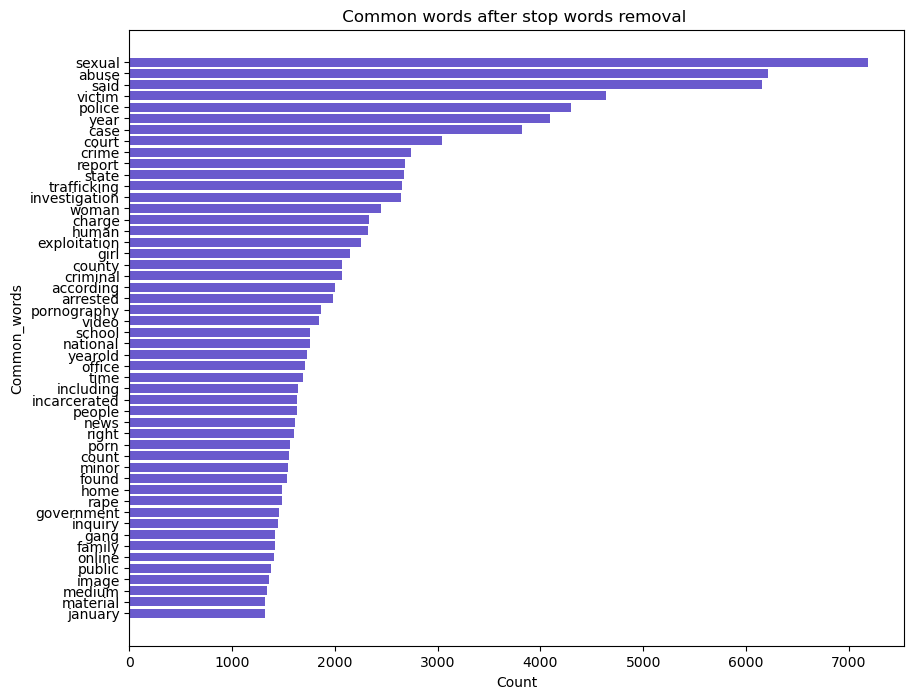

In [17]:
def Clean_Text(text):
    text = str(text).lower() # converting to lower
    text = " ".join([contractions.fix(expanded_word) for expanded_word in text.split()]) #Removing contractions
   # text = re.sub('\[.*?\]', '', text) # Removing text in square brackets
   # text = re.sub('https?://\S+|www\.\S+', '', text) #Removing links
    text = re.sub('[^a-zA-Z ]', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(punctuation), '', text) #Removing Punctuations
   # text = re.sub('\w*\d\w*', '', text) #Removing words containing numbers
    text = re.sub('\b\w{1,3}\b', '', text) #Any words less than 3 characters are replaced by blanks
    text = ' '.join(words for words in text.split() if len(words)>3)
    #print(text)
    tokenized_text = word_tokenize(str(text)) # Tokenizing text
    filtered_text = [word for word in tokenized_text if word not in stopwords.words('english')] #Removing stopwords
    text = [lemmatizer.lemmatize(word) for word in filtered_text] #Lemmatization
    text = ' '.join(text)
    text = re.sub("child|also|would|could|will|have|has|had|are|was|were","",text) #Removing the unused words commonly found in books
    text = ' '.join(words for words in text.split() if len(words)>3)
    text = re.sub("[\U0001F600-\U0001F64F]", '', text) # removing all emojis form the text
    text = ' '.join(words for words in text.split() if len(words)>3)
    return text
data_article['clean_text'] = data_article['article'].apply(lambda x : Clean_Text(x))

Cleansed_Text_df = ' '.join(data_article['clean_text'])
token_data = word_tokenize(str(Cleansed_Text_df))
top = Counter(word for word in token_data)
words = ' '.join(top)
count_words = len(words)
temp_df_after_cleansing = pd.DataFrame(top.most_common(50))
temp_df_after_cleansing.columns = ['Common_Words','Count']
temp_df_after_cleansing.style.background_gradient(cmap = 'Blues')

x = temp_df_after_cleansing['Common_Words']
y = temp_df_after_cleansing['Count']
plt.figure(figsize = (10,8))
#indexes = np.arange(len(y))
plt.title( " Common words after stop words removal  ")
plt.xlabel("Count")
plt.ylabel("Common_words")
plt.barh( x,y, color = 'slateblue')
plt.gca().invert_yaxis()
#addlabels(x, y)
plt.show()
#print("Total number of words:", count_words)

In [18]:
data_article

,article,no_sentences_before_cleansing,Text_with_stop_words,clean_text
0,At the High Court in Glasgow on Thursday Maria...,1,the high court glasgow thursday marian cumpana...,high court glasgow thursday marian cumpanasoiu...
1,LINCOLN State and federal law enforcement off...,1,lincoln state and federal law enforcement offi...,lincoln state federal enforcement official joi...
2,If you didnt know January is National Human Tr...,1,you did not know january national human traffi...,know january national human trafficking preven...
3,South African police rescued 26 Ethiopians fro...,1,south african police rescued ethiopian from su...,south african police rescued ethiopian suspect...
4,A joint operation between Sandringham SAPS Gau...,1,joint operation between sandringham sap gauten...,joint operation sandringham gauteng hawk johan...
...,...,...,...,...
2623,State Police investigators out of Lyons report...,1,state police investigator out lyon reported th...,state police investigator lyon reported arrest...
2624,Attorney General Alan Wilson Attorney General...,1,attorney general alan wilson attorney general ...,attorney general alan wilson attorney general ...
2625,Attorney General Alan Wilson Attorney General...,1,attorney general alan wilson attorney general ...,attorney general alan wilson attorney general ...
2626,MICHIGAN CITY Ind WNDU A 29yearold Michigan C...,1,michigan city ind wndu yearold michigan city m...,michigan city wndu yearold michigan city arres...


/Users/thavaseelan/anaconda3/lib/python3.11/site-packages/wordcloud/wordcloud.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.colormap = plt.cm.get_cmap(colormap)


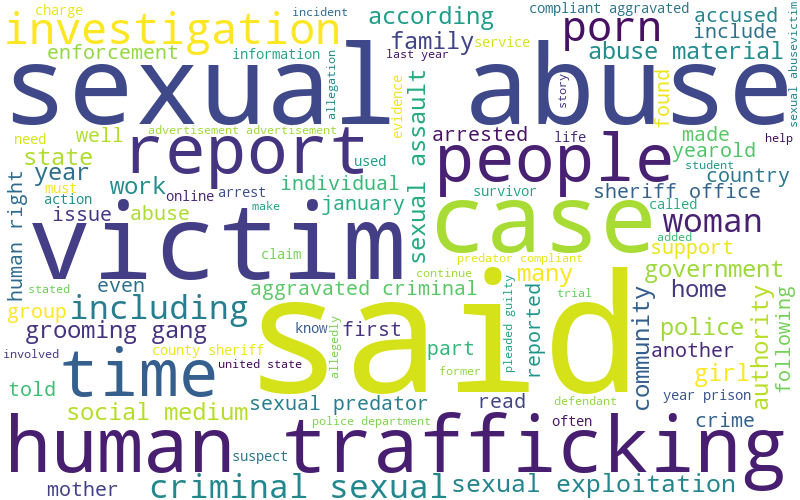

In [42]:
long_string = ','.join(list(data_article['clean_text'].values))
wordcloud = WordCloud(background_color="white", max_words=100, contour_width=3,width = 800, height = 500, contour_color='steelblue')
wordcloud.generate(long_string)
#plt.imshow(wordcloud)
wordcloud.to_image()


In [20]:
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])

def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc))
             if word not in stop_words] for doc in texts]


data_fn = data_article.clean_text.values.tolist()
data_words = list(sent_to_words(data_fn))

# remove stop words
data_words = remove_stopwords(data_words)

print(data_words[:1][0][:30])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/thavaseelan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['high', 'court', 'glasgow', 'thursday', 'marian', 'cumpanasoiu', 'remus', 'stan', 'calalan', 'dobre', 'cristian', 'urlanteanu', 'alexandra', 'bugonea', 'found', 'guilty', 'police', 'scotland', 'said', 'detective', 'said', 'gang', 'originally', 'romania', 'woman', 'hooked', 'drug', 'attempt', 'control', 'ensuring']


In [21]:
# Create Dictionary
id2word = corpora.Dictionary(data_words)

# Create Corpus
texts = data_words

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

# View
print(corpus[:1][0][:30])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 2), (24, 1), (25, 4), (26, 1), (27, 1), (28, 1), (29, 1)]


In [22]:
# number of topics
num_topics = 4

# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics,
                                       random_state=100,
                                       chunksize=100,
                                       passes=10,
                                       per_word_topics = True)

In [23]:
# Print the Keyword in the 4 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.014*"sexual" + 0.010*"county" + 0.009*"abuse" + 0.009*"pornography" + '
  '0.008*"said" + 0.008*"year" + 0.007*"arrested" + 0.007*"investigation" + '
  '0.007*"police" + 0.007*"video"'),
 (1,
  '0.020*"sexual" + 0.016*"abuse" + 0.009*"inquiry" + 0.008*"gang" + '
  '0.007*"grooming" + 0.007*"said" + 0.007*"victim" + 0.006*"report" + '
  '0.006*"police" + 0.005*"criminal"'),
 (2,
  '0.011*"court" + 0.011*"said" + 0.010*"case" + 0.009*"police" + '
  '0.009*"woman" + 0.007*"charge" + 0.007*"victim" + 0.005*"abuse" + '
  '0.005*"year" + 0.005*"judge"'),
 (3,
  '0.010*"trafficking" + 0.009*"human" + 0.006*"state" + 0.006*"said" + '
  '0.005*"victim" + 0.005*"right" + 0.004*"abuse" + 0.004*"case" + '
  '0.004*"forced" + 0.004*"exploitation"')]


In [24]:
#Compute Perplexity
print('Perplexity is:', lda_model.log_perplexity(corpus))
#Compute Coherence Score
coherence_model_lda = CoherenceModel(model = lda_model, texts=data_words, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('Coherence Score: ', coherence_lda)

Perplexity is: -8.131016262029572
Coherence Score:  0.4444829014780972


In [25]:
# supporting function
def compute_coherence_values(corpus, dictionary, k, a, b):

    lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                           id2word=dictionary,
                                           num_topics=k,
                                           random_state=200,
                                           chunksize=100,
                                           passes=20,
                                           alpha=a,
                                           eta=b)

    coherence_model_lda = CoherenceModel(model=lda_model, texts=data_words, dictionary=id2word, coherence='c_v')

    return coherence_model_lda.get_coherence()

In [26]:
"""start = time.perf_counter()
grid = {}
grid['Validation_Set'] = {}

# Topics range
min_topics = 2
max_topics = 11
step_size = 1
topics_range = range(min_topics, max_topics, step_size)

# Alpha parameter
alpha = list(np.arange(0.01, 1, 0.3))
alpha.append('symmetric')
alpha.append('asymmetric')

# Beta parameter
beta = list(np.arange(0.01, 1, 0.3))
beta.append('symmetric')

# Validation sets
num_of_docs = len(corpus)
corpus_sets = [gensim.utils.ClippedCorpus(corpus, int(num_of_docs*0.75)),
               corpus]

corpus_title = ['75% Corpus', '100% Corpus']

model_results = {'Validation_Set': [],
                 'Topics': [],
                 'Alpha': [],
                 'Beta': [],
                 'Coherence': []
                }

if 1 == 1:
    pbar = tqdm.tqdm(total=(len(beta)*len(alpha)*len(topics_range)*len(corpus_title)))
    for i in range(len(corpus_sets)):
        for k in topics_range:
            for a in alpha:
                for b in beta:
                    # get the coherence score for the given parameters
                    cv = compute_coherence_values(corpus=corpus_sets[i], dictionary=id2word,
                                                  k=k, a=a, b=b)
                    # Save the model results
                    model_results['Validation_Set'].append(corpus_title[i])
                    model_results['Topics'].append(k)
                    model_results['Alpha'].append(a)
                    model_results['Beta'].append(b)
                    model_results['Coherence'].append(cv)

                    pbar.update(1)
    pd.DataFrame(model_results).to_csv('C://Users//sdp950//Downloads//Source_files//human_traffik.csv', index=False)
    pbar.close()
elapsed_time = time.perf_counter() - start
print("Elapsed time is %.3f seconds." %elapsed_time)"""

'start = time.perf_counter()\ngrid = {}\ngrid[\'Validation_Set\'] = {}\n\n# Topics range\nmin_topics = 2\nmax_topics = 11\nstep_size = 1\ntopics_range = range(min_topics, max_topics, step_size)\n\n# Alpha parameter\nalpha = list(np.arange(0.01, 1, 0.3))\nalpha.append(\'symmetric\')\nalpha.append(\'asymmetric\')\n\n# Beta parameter\nbeta = list(np.arange(0.01, 1, 0.3))\nbeta.append(\'symmetric\')\n\n# Validation sets\nnum_of_docs = len(corpus)\ncorpus_sets = [gensim.utils.ClippedCorpus(corpus, int(num_of_docs*0.75)),\n               corpus]\n\ncorpus_title = [\'75% Corpus\', \'100% Corpus\']\n\nmodel_results = {\'Validation_Set\': [],\n                 \'Topics\': [],\n                 \'Alpha\': [],\n                 \'Beta\': [],\n                 \'Coherence\': []\n                }\n\nif 1 == 1:\n    pbar = tqdm.tqdm(total=(len(beta)*len(alpha)*len(topics_range)*len(corpus_title)))\n    for i in range(len(corpus_sets)):\n        for k in topics_range:\n            for a in alpha:\n 

In [27]:
num_topics = 4

lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                           id2word=id2word,
                                           num_topics=num_topics,
                                           random_state=100,
                                           chunksize=100,
                                           passes=10,
                                           alpha=0.7,
                                           eta=0.3)

In [28]:
def create_wordcloud(model, topic):
    text = {word: value for word, value in model.show_topic(topic)}
    wc = WordCloud(background_color="white", max_words=100)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Topic" + " "+ str(topic))
    plt.show()

/Users/thavaseelan/anaconda3/lib/python3.11/site-packages/wordcloud/wordcloud.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.colormap = plt.cm.get_cmap(colormap)


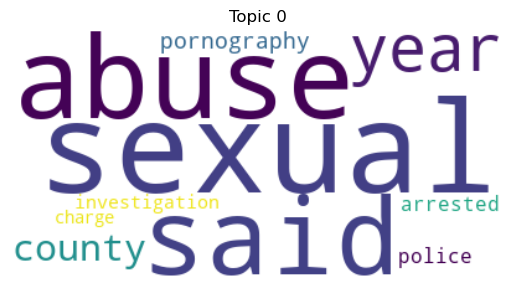

/Users/thavaseelan/anaconda3/lib/python3.11/site-packages/wordcloud/wordcloud.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.colormap = plt.cm.get_cmap(colormap)


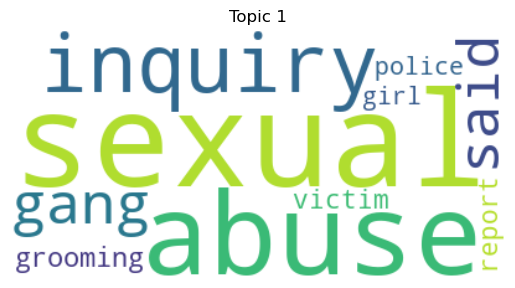

/Users/thavaseelan/anaconda3/lib/python3.11/site-packages/wordcloud/wordcloud.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.colormap = plt.cm.get_cmap(colormap)


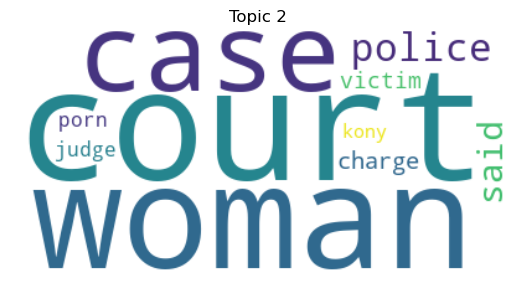

/Users/thavaseelan/anaconda3/lib/python3.11/site-packages/wordcloud/wordcloud.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.colormap = plt.cm.get_cmap(colormap)


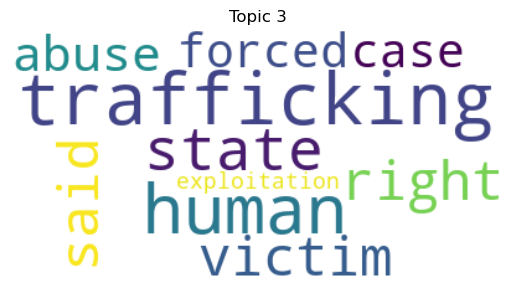

In [29]:
for i in range(0,num_topics):
    create_wordcloud(lda_model, topic=i)

In [30]:
start = time.perf_counter()
 # Visualize the topics
pyLDAvis.enable_notebook()

LDAvis_data_filepath = os.path.join('/Users/thavaseelan/Downloads/Dissertation/Topic Modelling'+str(num_topics))

if 1 == 1:
    LDAvis_prepared = pyLDAvis.gensim_models.prepare(lda_model, corpus, id2word)
    with open(LDAvis_data_filepath, 'wb') as f:
        pickle.dump(LDAvis_prepared, f)

# load the pre-prepared pyLDAvis data from disk
with open(LDAvis_data_filepath, 'rb') as f:
       LDAvis_prepared = pickle.load(f)

pyLDAvis.save_html(LDAvis_prepared, 'content_'+ str(num_topics) +'.html')

elapsed_time = time.perf_counter() - start
print("Elapsed time is %.2f seconds." %elapsed_time)
LDAvis_prepared


Elapsed time is 8.38 seconds.


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.129766  0.027690       1        1  30.198655
0      0.150395 -0.108390       2        1  29.980105
1     -0.111952 -0.061616       3        1  21.570326
2      0.091322  0.142316       4        1  18.250913, topic_info=             Term         Freq        Total Category  logprob  loglift
75         sexual  6521.000000  6521.000000  Default  30.0000  30.0000
88    trafficking  2255.000000  2255.000000  Default  29.0000  29.0000
44          human  1998.000000  1998.000000  Default  28.0000  28.0000
130        county  1951.000000  1951.000000  Default  27.0000  27.0000
19          court  3012.000000  3012.000000  Default  26.0000  26.0000
...           ...          ...          ...      ...      ...      ...
279          year   505.220380  3928.585952   Topic4  -5.5832  -0.3501
20          crime   463.264875  2844.435539   Topic4  -5.6699  -0.1139
821         count   364.535330  1412.446452   Topic4  -5.9096   0.3465
1715        video   367.372491  1732.791204   Topic4  -5.9018   0.1498
656         abuse   361.364364  6222.380758   Topic4  -5.9183  -1.1451

[319 rows x 6 columns], token_table=       Topic      Freq         Term
term                               
656        1  0.153157        abuse
656        2  0.361919        abuse
656        3  0.426846        abuse
656        4  0.058016        abuse
16461      3  0.997663  abusevictim
...      ...       ...          ...
1034       2  0.268840        young
1034       3  0.490790        young
1034       4  0.082319        young
7183       2  0.006719       yvette
7183       3  0.987739       yvette

[603 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 1, 2, 3])

In [31]:
from sklearn.manifold import TSNE
from bokeh.plotting import figure, output_file, show
from bokeh.models import Label
from bokeh.io import output_notebook

# Get topic weights
topic_weights = []
for i, row_list in enumerate(lda_model[corpus]):
    topic_weights.append([w for i, w in row_list])

# Array of topic weights
arr = pd.DataFrame(topic_weights).fillna(0).values

# Keep the well separated points (optional)
arr = arr[np.amax(arr, axis=1) > 0.0001]

# Dominant topic number in each doc
topic_num = np.argmax(arr, axis=1)

# tSNE Dimension Reduction
tsne_model = TSNE(n_components=2, verbose=1, random_state=0, angle=.99, init='pca', perplexity=0.8)
tsne_lda = tsne_model.fit_transform(arr)

# Plot the Topic Clusters using Bokeh
output_notebook()
n_topics = 4
mycolors = np.array([color for name, color in mcolors.TABLEAU_COLORS.items()])
plot = figure(title="t-SNE Clustering of {} LDA Topics".format(n_topics))
plot.scatter(x=tsne_lda[:,0], y=tsne_lda[:,1], color=mycolors[topic_num])
show(plot)

[t-SNE] Computing 3 nearest neighbors...
[t-SNE] Indexed 2628 samples in 0.007s...
[t-SNE] Computed neighbors for 2628 samples in 0.012s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2628
[t-SNE] Computed conditional probabilities for sample 2000 / 2628
[t-SNE] Computed conditional probabilities for sample 2628 / 2628
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 84.040253
[t-SNE] KL divergence after 1000 iterations: 1.007092


Loading BokehJS ...

In [32]:
## Metrics

In [33]:
# Perplexity score
perplexity = lda_model.log_perplexity(corpus)
print(f"Perplexity: {perplexity}")

Perplexity: -8.150061129127453


In [34]:
# Calculate coherence score
coherence_model_lda = CoherenceModel(model=lda_model, texts=texts, dictionary=id2word, coherence='c_v')
coherence_score = coherence_model_lda.get_coherence()
print(f"Coherence Score: {coherence_score}")

Coherence Score: 0.4411570812558929


In [35]:
# Get the top words for each topic
top_words_per_topic = [lda_model.show_topic(i, topn=10) for i in range(lda_model.num_topics)]

# Flatten list of words
all_words = [word for topic in top_words_per_topic for word, _ in topic]

# Calculate unique words
unique_words = len(set(all_words))

# Topic diversity (unique words / total words in all topics)
topic_diversity = unique_words / len(all_words)
print(f"Topic Diversity: {topic_diversity}")

Topic Diversity: 0.7


In [36]:
Perplexity: Measures model fit. Lower values are better.
Coherence Score: Measures the interpretability of topics. Higher values are better.
Topic Diversity: Measures the distinctiveness of topics. Higher values are better

SyntaxError: invalid syntax (2215380345.py, line 1)